In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

Start learning at 2026-07-29 23:43:04.370857


100%|██████████| 792M/792M [00:44<00:00, 17.8MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.5MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [32, 64, 128, 128]           1,792
              ReLU-2         [32, 64, 128, 128]               0
         MaxPool2d-3           [32, 64, 64, 64]               0
            Conv2d-4          [32, 128, 64, 64]          73,856
              ReLU-5          [32, 128, 64, 64]               0
         MaxPool2d-6          [32, 128, 32, 32]               0
            Conv2d-7          [32, 256, 32, 32]         295,168
              ReLU-8          [32, 256, 32, 32]               0
         MaxPool2d-9          [32, 256, 16, 16]               0
           Conv2d-10          [32, 512, 16, 16]       1,180,160
             ReLU-11          [32, 512, 16, 16]               0
  ConvTranspose2d-12          [32, 256, 32, 32]         524,544
           Conv2d-13          [32, 256, 32, 32]       1,179,904
             ReLU-14          [32, 256,

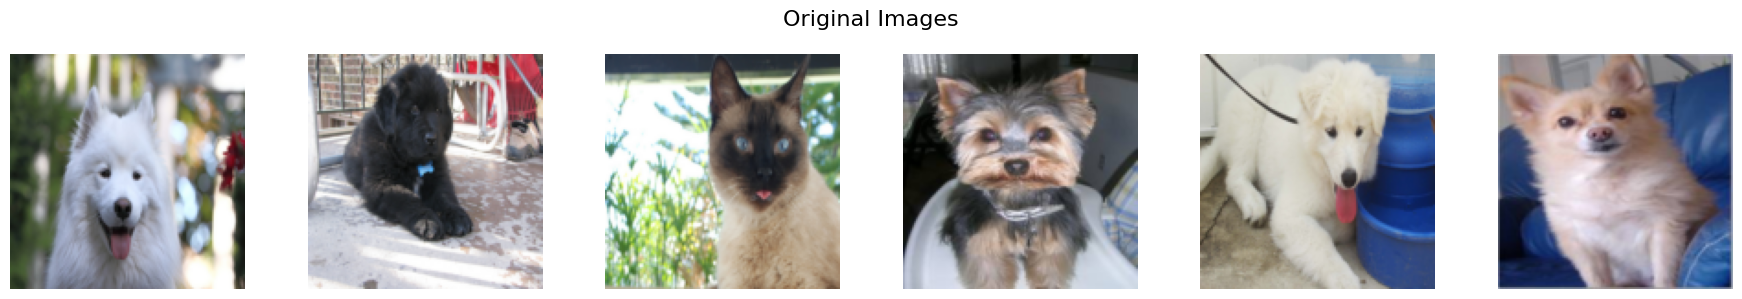

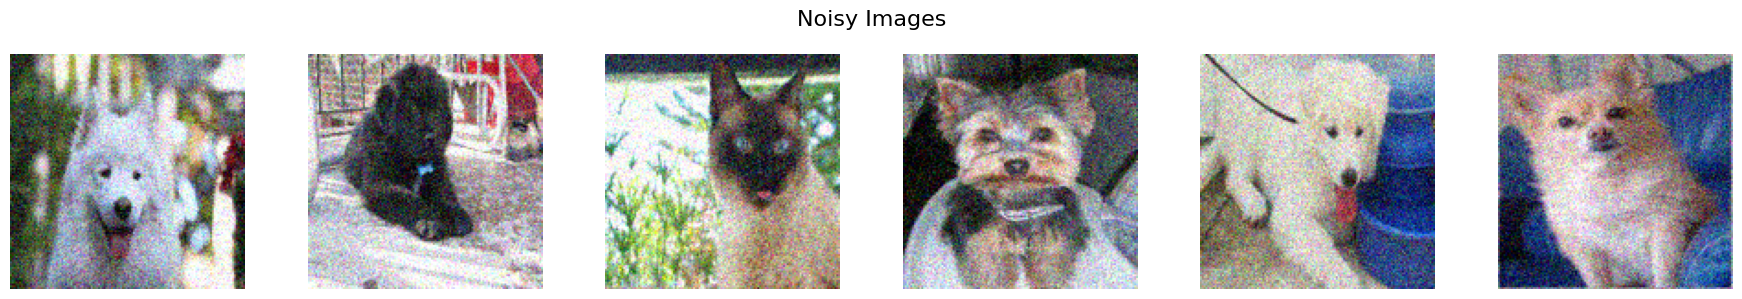

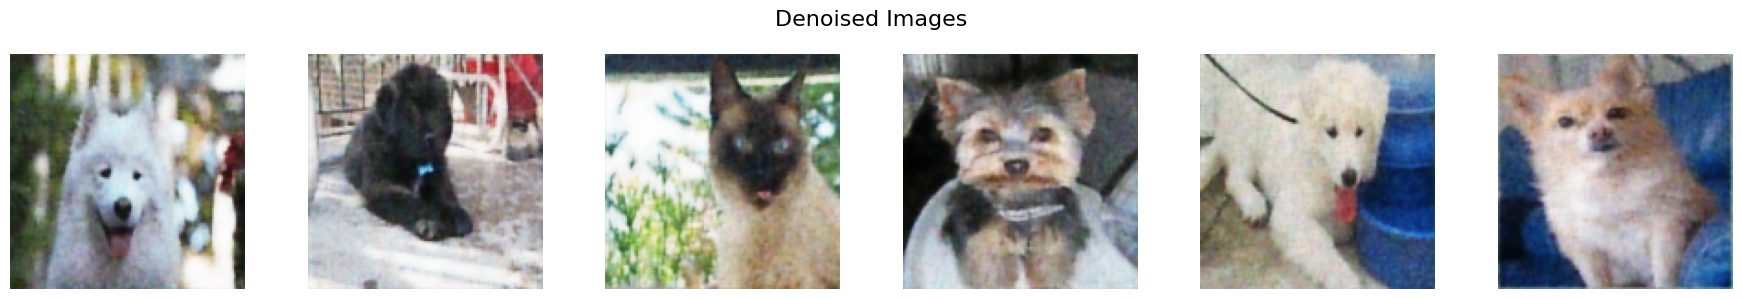

Stop learning at 2026-07-30 02:59:44.980198
Elapsed learning time: 3:16:40.609341


In [4]:
import datetime as dt
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchsummary import summary
from google.colab import drive


# Define the autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding='same'),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding='same'),
            nn.ReLU()
        )
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding='same'),
            nn.ReLU()
        )
        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding='same'),  # skip cat, so 256+256
            nn.ReLU()
        )
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding='same'),  # 128+128
            nn.ReLU()
        )
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding='same'),   # 64+64
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding='same'),     # Final output
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)        # (B, 64, 128, 128)
        p1 = self.pool1(e1)      # (B, 64, 64, 64)
        e2 = self.enc2(p1)       # (B, 128, 64, 64)
        p2 = self.pool2(e2)      # (B, 128, 32, 32)
        e3 = self.enc3(p2)       # (B, 256, 32, 32)
        p3 = self.pool3(e3)      # (B, 256, 16, 16)
        e4 = self.enc4(p3)       # (B, 512, 16, 16)
        # Decoder with skip connections
        d3 = self.up3(e4)        # (B, 256, 32, 32)
        d3 = torch.cat([d3, e3], dim=1) # (B, 512, 32, 32)
        d3 = self.dec3(d3)       # (B, 256, 32, 32)
        d2 = self.up2(d3)        # (B, 128, 64, 64)
        d2 = torch.cat([d2, e2], dim=1) # (B, 256, 64, 64)
        d2 = self.dec2(d2)       # (B, 128, 64, 64)
        d1 = self.up1(d2)        # (B, 64, 128, 128)
        d1 = torch.cat([d1, e1], dim=1) # (B, 128, 128, 128)
        out = self.dec1(d1)      # (B, 3, 128, 128)
        return out

def add_noise(images, noise_factor=0.1):
    noisy_images = images + noise_factor * torch.randn_like(images)
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

def compute_snr(clean, noisy):
    # SNR = 10 * log10(signal_power / noise_power)
    signal_power = torch.mean(clean ** 2)
    noise_power = torch.mean((clean - noisy) ** 2)
    snr = 10 * torch.log10(signal_power / (noise_power + 1e-8))
    return snr.item()

def compute_mse(clean, noisy):
    return torch.mean((clean - noisy) ** 2).item()

def show(imgs, title):
    fig, axs = plt.subplots(
        ncols=len(imgs),
        figsize=(18, 3),
        squeeze=False
    )

    for i, img in enumerate(imgs):
        img = img.detach().cpu().numpy()
        img = np.transpose(img, (1, 2, 0))
        img = np.clip(img, 0, 1)

        axs[0, i].imshow(img)
        axs[0, i].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
# Monitor start time
start_time = dt.datetime.now()
print('Start learning at {}'.format(str(start_time)))

# Data loading & transformation
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

full_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform)
subset_indices = list(range(1000))  # Use only the first 100 samples
small_dataset = Subset(full_dataset, subset_indices)
train_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)

subset_indices = list(range(1000,2000))  # Use only 100-200 samples
small_dataset = Subset(full_dataset, subset_indices)
test_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)


# Model, Loss, Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder().to(device)
summary(model, input_size=(3, 128, 128), batch_size=32)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 15
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model.train()
    running_loss = 0.0
    for data, _ in train_loader:
        data = data.to(device)
        noisy_data = add_noise(data)
        outputs = model(noisy_data)
        loss = criterion(outputs, data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)

    epoch_loss = running_loss / len(small_dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')


# --- Testing Section ---
# Load a trained model
model.eval()

# Gather some samples for visualization and SNR/MSE calculation
test_samples = []
noisy_samples = []
denoised_samples = []

with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)
        noisy_data = add_noise(data)
        outputs = model(noisy_data)

        test_samples.append(data)
        noisy_samples.append(noisy_data)
        denoised_samples.append(outputs)
        if len(test_samples) * data.size(0) >= 32:  # Only collect up to 32 samples
            break

test_samples = torch.cat(test_samples)[:6]
noisy_samples = torch.cat(noisy_samples)[:6]
denoised_samples = torch.cat(denoised_samples)[:6]

# Calculate SNR and MSE
snr_before = compute_snr(test_samples, noisy_samples)
mse_before = compute_mse(test_samples, noisy_samples)
snr_after = compute_snr(test_samples, denoised_samples)
mse_after = compute_mse(test_samples, denoised_samples)

print(f"SNR before denoising: {snr_before:.2f} dB | MSE: {mse_before:.6f}")
print(f"SNR after  denoising: {snr_after:.2f} dB | MSE: {mse_after:.6f}")

# Visualization
show(test_samples, "Original Images")
show(noisy_samples, "Noisy Images")
show(denoised_samples, "Denoised Images")

# Monitor end time
end_time = dt.datetime.now()
print('Stop learning at {}'.format(str(end_time)))
elapsed_time = end_time - start_time
print('Elapsed learning time: {}'.format(str(elapsed_time)))